# 量子機械学習とTTN
量子機械学習のモデルとして、木構造テンソルネットワーク(Tree Tensor Network, TTN)を見ていきましょう。

## 今回学ぶこと
1. TTNモデル
2. 最適化

これから構築するモデルはTTNと呼ばれます。量子回路は以下の通りです。

(現在、画像はありません)

木構造の形をしています。
この回路は、1量子ビットの任意回転ゲート($Rx$, $Rz$, $Ry$ゲートの組み合わせ)と、2量子ビットゲート($CX$ゲート)を使用します。
詳細は以下の通りです。

```
|0> -RX-RY-RZ--CX--
               |
|0> -RX-RY-RZ--CX--RX-RY-RZ--CX--
                             |
|0> -RX-RY-RZ--CX--          |
               |             |
|0> -RX-RY-RZ--CX--RX-RY-RZ--CX--M

```

In [1]:
from blueqat import Circuit
from blueqat.utils import Z
import matplotlib.pyplot as plt
import numpy as np
import time
%matplotlib inline

ハイパーパラメータなどの設定を行います。

In [2]:
np.random.seed(45)

nsteps = 2000
nparams = 18
h = 0.01
e = 0.01

param_init = [np.random.rand()*np.pi*2 for i in range(nparams)]

arr = []

mode = 1

木構造のモデルを作成します。
量子回路への入力とそれに対する目標ラベルを設定し、学習を開始します。
今回は、引数によって入力データを選択できます。

In [3]:
def TTN_Z(a, ran, mode=1):
    
    # Input circuit
    init = [Circuit(4).x[0,1], Circuit(4).x[2,3], Circuit(4).x[0], Circuit(4).x[1], Circuit(4).x[2], Circuit(4).x[0,2]]
    # Target label
    target = [1,1,-1,-1,-1,1]
   
    # Circuit construct}ion
    u = init[ran]
    u.rx(a[0])[0].ry(a[1])[0].rz(a[2])[0]
    u.rx(a[3])[1].ry(a[4])[1].rz(a[5])[1]
    u.rx(a[6])[2].ry(a[7])[2].rz(a[8])[2]
    u.rx(a[9])[3].ry(a[10])[3].rz(a[11])[3]
    u.cx[0,1].cx[2,3]
    u.rx(a[12])[1].ry(a[13])[1].rz(a[14])[1]
    u.rx(a[15])[3].ry(a[16])[3].rz(a[17])[3]
    u.cx[1,3]
    
    # Calculate expectation value from state vector
    expt = u.run(hamiltonian=1*Z[3])
    
    if(mode ==1):
        # return error between label and prediction
        return (expt - target[ran])**2
    else:
        return expt

学習には確率的勾配降下法(SGD)を使用します。
各ステップの開始時に、入力データを6通り(0から5)からランダムに選び、勾配を計算してパラメータを更新します。

各ステップでは1つのデータについてのみ勾配計算とパラメータ更新を行いますが、入力データをランダムに選びながらこの処理を繰り返すことで、最終的にすべてのデータに対して損失関数を最小化するように学習が進みます。

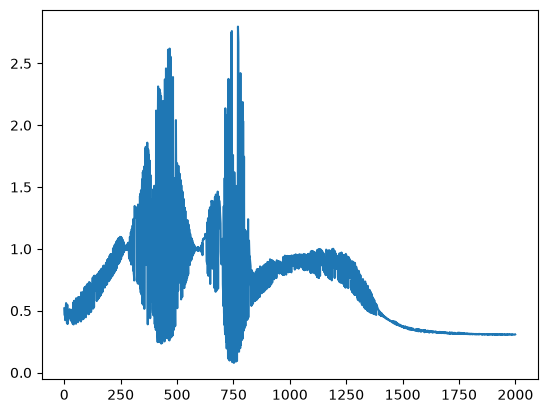

39.65912222862244


In [4]:
start = time.time()

param = param_init.copy()
for i in range(nsteps):
    it = np.random.randint(0,6)
    
    loss = TTN_Z(param, it, mode)
    arr.append(loss)
    param_new = [0 for i in range(nparams)]
    
    for j in range(nparams):
        _param = param.copy()
        _param[j] += h
        param_new[j] = param[j] - e*(TTN_Z(_param, it, mode) - loss)/h

    param = param_new

plt.plot(arr)
plt.show()
print(time.time() - start)

うまく収束しました。
確認してみましょう。

In [5]:
target = [1,1,-1,-1,-1,1]
preds = []
for i in range(6):
    pred = TTN_Z(param, i, mode=2)
    preds.append(pred)
    print("Prediction :", pred, "        Target :", target[i])

Prediction : tensor(0.4462, dtype=torch.float64)         Target : 1
Prediction : tensor(0.4450, dtype=torch.float64)         Target : 1
Prediction : tensor(-0.4462, dtype=torch.float64)         Target : -1
Prediction : tensor(-0.4464, dtype=torch.float64)         Target : -1
Prediction : tensor(-0.4450, dtype=torch.float64)         Target : -1
Prediction : tensor(0.4448, dtype=torch.float64)         Target : 1


以上により、TTNモデルを使って量子回路を学習させることができました。

# 量子機械学習とMPS
量子機械学習のモデルとして、木構造テンソルネットワークを見ていきましょう。

## 今回学ぶこと
1. MPSモデル
2. 最適化

これから構築するモデルはMPSと呼ばれます。この回路は、1量子ビットの任意回転ゲート($Rz$と$Ry$ゲートの組み合わせ)と、2量子ビットゲート($CX$ゲート)を使用します。
詳細は以下の通りです。

```
|0> -RX-RY-RZ--CX--
               |
|0> -RX-RY-RZ--CX--RX-RY-RZ--CX--
                             |
|0> -RX-RY-RZ----------------CX--RX-RY-RZ--CX--
                                           |
|0> -RX-RY-RZ------------------------------CX--M

```

ハイパーパラメータなどの設定を行います。

In [6]:
np.random.seed(45)

# Number of steps of optimizetaion
nsteps = 5000

# Number of parameters of the quantum circuit to be optimized
nparams = 18

# Fineness of numerical differentiation
h = 0.01

# Learning rate
e = 0.01

# Initial parameter
param_init = [np.random.rand() * np.pi * 2 for i in range(nparams)]

# list for containing results
arr = []

# 1: train, 2: prediction
mode = 1

In [7]:
def mpsZ(a, ran, mode=1):
    
    # Input circuit
    init = [Circuit(4).x[0,1], Circuit(4).x[2,3], Circuit(4).x[0], Circuit(4).x[1], Circuit(4).x[2], Circuit(4).x[0,2]]
    # Target label
    target = [1, 1, -1, -1, -1, 1]
   
    # Circuit construction
    u = init[ran]
    u.rx(a[0])[0].ry(a[1])[0].rz(a[2])[0]
    u.rx(a[3])[1].ry(a[4])[1].rz(a[5])[1]    
    u.rx(a[6])[2].ry(a[7])[2].rz(a[8])[2]
    u.rx(a[9])[3].ry(a[10])[3].rz(a[11])[3]
    u.cx[0,1]
    u.rx(a[12])[1].ry(a[13])[1].rz(a[14])[1]
    u.cx[1,2]
    u.rx(a[15])[2].ry(a[16])[2].rz(a[17])[2]
    u.cx[2,3]
    
    # Calculate expectation value from state vector
    expt = u.run(hamiltonian=1*Z[3])
    
    if(mode ==1):
        # return error between label and prediction
        return (expt - target[ran]) ** 2
    else:
        return expt

学習には確率的勾配降下法(SGD)を使用します。
各ステップの開始時に、入力データを6通り(0から5)からランダムに選び、勾配を計算してパラメータを更新します。

各ステップでは1つのデータについてのみ勾配計算とパラメータ更新を行いますが、入力データをランダムに選びながらこの処理を繰り返すことで、最終的にすべてのデータに対して損失関数を最小化するように学習が進みます。

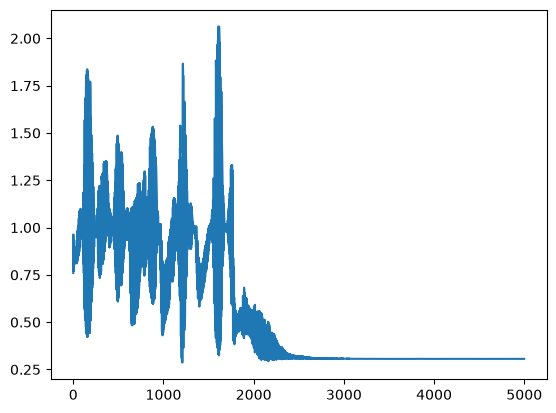

100.72694969177246


In [8]:
start = time.time()

param = param_init.copy()

for i in range(nsteps):
    it = np.random.randint(0,6)
    
    loss = mpsZ(param, it)
    arr.append(loss)
    param_new = [0 for i in range(nparams)]
    
    for j in range(nparams):
        _param = param.copy()
        _param[j] += h
        param_new[j] = param[j] - e*(mpsZ(_param, it) - loss) / h

    param = param_new

plt.plot(arr)
plt.show()
print(time.time() - start)

うまく収束しました。
確認してみましょう。

In [9]:
target = [1,1,-1,-1,-1,1]
preds = []
for i in range(6):
    pred = mpsZ(param, i, mode=2)
    preds.append(pred)
    print("Prediction :", pred, "        Target :", target[i])

Prediction : tensor(0.4467, dtype=torch.float64)         Target : 1
Prediction : tensor(0.4467, dtype=torch.float64)         Target : 1
Prediction : tensor(-0.4468, dtype=torch.float64)         Target : -1
Prediction : tensor(-0.4468, dtype=torch.float64)         Target : -1
Prediction : tensor(-0.4467, dtype=torch.float64)         Target : -1
Prediction : tensor(0.4468, dtype=torch.float64)         Target : 1
